# 00 — Define Region Polygon

Define the study area and coffee-farm labels for the Kona Coffee Belt.

Coffee farm polygons come from the **Hawaii 2020 Agricultural Land Use Baseline**
(Hawaii Statewide GIS Program).  592 polygons labeled `Crops_2020 = 'Coffee'` fall
within the Kona bounding box — no manual drawing needed.

Outputs:
- `../data/polygons/kona_region.geojson` — bounding polygon for the study area
- `../data/polygons/kona_coffee_farms.geojson` — 592 real coffee-farm polygons (label = 1)

In [1]:
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import os

OUT_DIR  = '../data/polygons'
SHP_PATH = '../data/polygons/aglanduse_2020.shp'

os.makedirs(OUT_DIR, exist_ok=True)

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## Region boundary

Derived from the actual coffee farm polygons — buffered union of all Kona + Ka'ū parcels.
Using union (not convex hull) preserves the natural U-shape around Mauna Loa's west and
south slopes without filling in the empty mountain interior.

In [2]:
# Load coffee farms first (needed to derive the region boundary)
ag = gpd.read_file(SHP_PATH).to_crs('EPSG:4326')

# Kona (west slope) + Ka'ū (south slope) — both on Mauna Loa's flanks
# Lat ceiling 19.80 excludes the 3 stray Waimea/Hamakua polygons at 20.03–20.09°N
MAUNA_LOA_BBOX = (-156.10, 18.90, -155.40, 19.80)  # minx, miny, maxx, maxy

coffee_all = ag[ag['Crops_2020'] == 'Coffee']
farms_gdf  = coffee_all.cx[
    MAUNA_LOA_BBOX[0]:MAUNA_LOA_BBOX[2],
    MAUNA_LOA_BBOX[1]:MAUNA_LOA_BBOX[3]
].copy()
farms_gdf  = farms_gdf.reset_index(drop=True)
farms_gdf['label'] = 1

print(f'Coffee polygons (Kona + Kaʻū): {len(farms_gdf)}')
print(f'Total acreage:                 {farms_gdf["Acreage"].sum():.1f} acres')
print(f'Farm bounds: lon {farms_gdf.total_bounds[0]:.4f} to {farms_gdf.total_bounds[2]:.4f}')
print(f'             lat {farms_gdf.total_bounds[1]:.4f} to {farms_gdf.total_bounds[3]:.4f}')

# Build region: buffered union of farms (no convex hull) — preserves U-shape
farms_utm  = farms_gdf.to_crs('EPSG:32604')
region_utm = farms_utm.unary_union.buffer(2000)  # 2 km buffer
region_gdf = gpd.GeoDataFrame(
    {'name': ['mauna_loa_belt'], 'geometry': [region_utm]}, crs='EPSG:32604'
).to_crs('EPSG:4326')

region_gdf.to_file(os.path.join(OUT_DIR, 'kona_region.geojson'), driver='GeoJSON')
farms_gdf.to_file(os.path.join(OUT_DIR, 'kona_coffee_farms.geojson'), driver='GeoJSON')
print('Saved kona_region.geojson')
print('Saved kona_coffee_farms.geojson')

Coffee polygons (Kona + Kaʻū): 674
Total acreage:                 5986.0 acres
Farm bounds: lon -155.9859 to -155.4568
             lat 19.0606 to 19.7399
Saved kona_region.geojson
Saved kona_coffee_farms.geojson


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
No handles with labels found to put in legend.


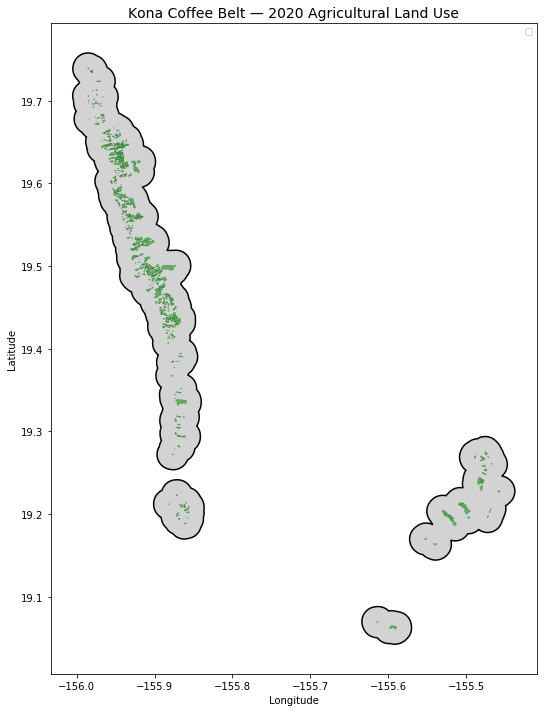

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))
region_gdf.plot(ax=ax, facecolor='lightgrey', edgecolor='black', linewidth=1.5,
                label='Study region (convex hull + 2 km buffer)')
farms_gdf.plot(ax=ax, facecolor='#2ca02c', edgecolor='darkgreen',
               linewidth=0.3, alpha=0.7, label=f'Coffee farms (n={len(farms_gdf)})')
ax.set_title('Kona Coffee Belt — 2020 Agricultural Land Use', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../img/00_region.png', dpi=150)
plt.show()

In [4]:
# Export region as KML for upload to USGS TNM downloader
# https://apps.nationalmap.gov/downloader/ → Upload File → search for 1m DEM tiles
from shapely.geometry import MultiPolygon, Polygon

geom = region_gdf.geometry.iloc[0]
polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]

placemark_blocks = []
for i, poly in enumerate(polys):
    coords = ' '.join(f'{x},{y},0' for x, y in poly.exterior.coords)
    placemark_blocks.append(f'''  <Placemark>
    <name>mauna_loa_belt_{i}</name>
    <Polygon>
      <outerBoundaryIs>
        <LinearRing>
          <coordinates>{coords}</coordinates>
        </LinearRing>
      </outerBoundaryIs>
    </Polygon>
  </Placemark>''')

kml = '<?xml version="1.0" encoding="UTF-8"?>\n'
kml += '<kml xmlns="http://www.opengis.net/kml/2.2">\n<Document>\n'
kml += '\n'.join(placemark_blocks)
kml += '\n</Document>\n</kml>'

kml_path = os.path.join(OUT_DIR, 'kona_region.kml')
with open(kml_path, 'w') as f:
    f.write(kml)

print(f'Saved {kml_path}  ({len(polys)} polygon parts)')

Saved ../data/polygons/kona_region.kml  (4 polygon parts)
